In [2]:
import numpy as np
import matplotlib.pyplot as pl

## W < L

In [65]:
sampling_freq = 2048
duration = 1e2
t = np.arange(-2*duration//3, 1*duration//3, 1/sampling_freq)

f0 = 20
phase = 2*np.pi*f0*t
heaviside = np.heaviside(t, 0)
waveform = np.real(np.exp(1j*phase))
short_waveform = heaviside*waveform

noise = np.random.normal(0, 1e0, len(t))
signal = waveform + nose
short_signal = short_waveform + noise

In [66]:
freqs = np.fft.fftshift(np.fft.fftfreq(len(signal), d=t[1]-t[0]))

long_power = abs(np.fft.fftshift(np.fft.fft(signal)))**2
short_power = abs(np.fft.fftshift(np.fft.fft(short_signal)))**2

(19.0, 21.0)

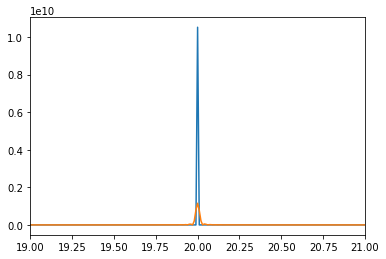

In [67]:
pl.plot(freqs, long_power)
pl.plot(freqs, short_power)
pl.xlim(19, 21)

In [68]:
print("Ratio = %.2f" % (np.max(long_power)/np.max(short_power)))

Ratio = 9.13


In [69]:
SNR_long = np.max(long_power)/np.median(long_power)
SNR_short = np.max(short_power)/np.median(short_power)
print(SNR_long/SNR_short)

9.14729309609239


## W > L

In [123]:
sampling_freq = 2048
duration = 1e3
t_short = np.arange(0, duration//3, 1/sampling_freq)
t_long = np.arange(0, duration, 1/sampling_freq)

f0 = 20
phase = 2*np.pi*f0*t_short
waveform_short = np.real(np.exp(1j*phase))
waveform_long = np.pad(waveform_short, (0, len(t_long) - len(t_short)), 
                       'constant', constant_values=0)

# pl.plot(t_short, waveform_short - waveform_long[:len(waveform_long)//2])
# pl.plot(t_long, waveform_long)

noise_short = np.random.normal(0, 1e-1, len(t_short))
noise_long = np.random.normal(0, 1e-1, len(t_long))

signal_short = waveform_short + noise_short
signal_long = waveform_long + noise_long

# pl.plot(t_short, signal_short - signal_long[:len(waveform_long)//2])
# pl.plot(t_long, signal_long)

In [124]:
freqs_short = np.fft.fftshift(np.fft.fftfreq(len(signal_short), d=t[1]-t[0]))
freqs_long = np.fft.fftshift(np.fft.fftfreq(len(signal_long), d=t[1]-t[0]))

power_short = abs(np.fft.fftshift(np.fft.fft(signal_short)))**2
power_long = abs(np.fft.fftshift(np.fft.fft(signal_long)))**2

(19.9, 20.1)

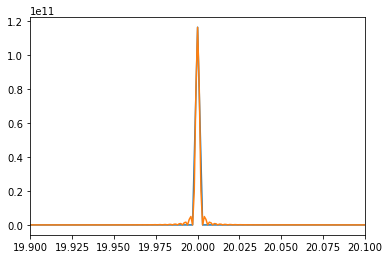

In [125]:
pl.plot(freqs_short, power_short)
pl.plot(freqs_long, power_long)
pl.xlim(19.9, 20.1)

In [126]:
SNR_short = np.max(power_short)/np.median(power_short)
SNR_long = np.max(power_long)/np.median(power_long)
print(SNR_long/SNR_short)

0.3299789959005314


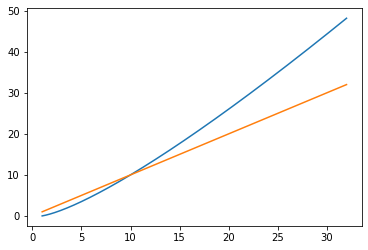

In [132]:
N_space = np.linspace(1, 32, 1000)
pl.plot(N_space, N_space*np.log10(N_space))
pl.plot(N_space, N_space)

In [131]:
1/np.sqrt(2)

0.7071067811865475

In [134]:
np.arctan(20/8000)

0.0024999947916861977